# Chapter 20: Messages, Beliefs, and Consensus

Alice sends a handoff and Bob receives it. Bob sends an acknowledgement, but Alice may never see that reply. Bob knows the request arrived; he does not automatically know that Alice knows it arrived. A protocol that treats one receipt as shared certainty can therefore split the parties' decisions.

This notebook enumerates a bounded request-and-acknowledgement protocol. Alice commits after seeing an acknowledgement. Bob commits after seeing a request. Each party's local view is compared with every positive-probability world that looks the same to that party. The calculation reports agreement and limited knowledge separately. It does not turn a finite retry budget into a proof of common knowledge or asynchronous consensus.

**Outcome:** Enumerate bounded message worlds and distinguish agreement from local knowledge.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Each round has two potential delivery bits: request delivery and acknowledgement delivery. An acknowledgement exists only when that round's request arrives. With R rounds, the enumeration contains 2^(2R) constructed bit worlds. Their weights multiply independent delivery or drop probabilities.

A party's view contains its local sends, received messages, and round ticks. Two worlds are indistinguishable to that party when these views match. Alice knows delivery in a world if every positive-probability world with her view contains at least one received request. Bob knows Alice received an acknowledgement only if every world with his view contains that acknowledgement receipt.

Agreement compares Alice's acknowledgement-based commit with Bob's request-based commit. Disagreement occurs when Bob received some request but Alice received no acknowledgement. With drop probability d, its probability after R rounds is [1-(1-d)^2]^R-d^R. The first term means no successful request/ack pair; the second removes worlds where no request arrived at all. This is a bounded protocol calculation under a specific independent-drop law.

## A calculation you can run

Supply a round budget and message-drop probability. The code enumerates bit histories, builds local views, and retains only positive-probability worlds for knowledge tests. Excluding impossible worlds matters at d=0 or d=1, where the declared probability model itself rules out certain histories.

The metrics report world counts, agreement, Alice's delivery knowledge, Bob's acknowledgement-receipt knowledge, and Bob-only commitment. The chart uses request rounds on the horizontal axis and agreement probability on the vertical axis. Compare its analytic values with the enumerated final metric. In the changed case set drops to zero; predict how the possible-world set shrinks before rerunning. The transfer case checks a longer budget at a different loss probability.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 20
inputs = {'rounds': 2, 'drop_probability': 0.3}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 20: bounded-message-knowledge
What can each party know after a request and an acknowledgement can be dropped?
Evidence: constructed teaching example

Calculated quantities:
{
  "enumerated_worlds": 16,
  "possible_worlds": 16,
  "agreement_probability": 0.8299,
  "alice_knows_delivery_probability": 0.7399,
  "bob_knows_ack_receipt_probability": 0.0,
  "bob_commits_without_alice_probability": 0.1701
}

Interpretation:
Alice commits after an acknowledgement; Bob commits after a request. Local knowledge is checked over indistinguishable positive-probability bounded histories.

Assumptions:
- Independent drops per message opportunity.
- Bob does not observe whether his acknowledgement arrived.
- The model contains a fixed bounded number of rounds.

Limitations:
- Finite agreement probability is not common knowledge or an asynchronous consensus theorem.
- No hidden timeout, failure detector, or extra receipt is assumed.

Execution: completed locally; constructed inputs are not deplo

At d=0.3 and R=2, no successful request/ack pair has probability 0.51^2=0.2601. No request arrives with probability 0.3^2=0.09. Bob-only commitment therefore has probability 0.1701, and agreement has probability 0.8299.

With zero drops, only one positive-probability world remains. Requests and acknowledgements arrive, so both parties commit and agreement is 1. Bob can know acknowledgement receipt in this restricted model because delivery failure has been declared impossible. That conclusion depends on the model assumption, not on receiving an additional receipt.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


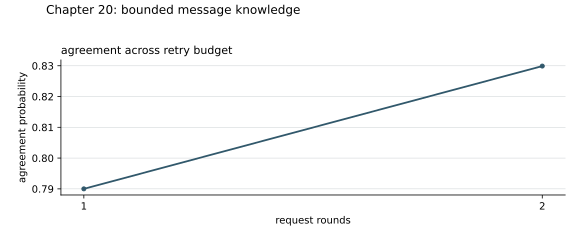

In [3]:
display(SVG(figure_svg(report)))

**Figure 20.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Increasing retries does not monotonically create stronger epistemic guarantees. It can alter agreement probability while leaving Bob unable to distinguish a lost acknowledgement from a delivered one. Probability of agreement and knowledge of agreement are different quantities.

The bounded model also supplies synchronized round ticks and independent message losses. Real asynchronous systems may lack those assumptions or face crashes rather than simple drops. This notebook makes no impossibility or consensus theorem claim for those broader settings.

A zero-drop result is especially easy to overread. Declaring failure probability zero removes alternate worlds by assumption. It does not prove the channel cannot fail. When the channel contract is uncertain, retain the plausible loss worlds and identify what extra receipt, timeout rule, or failure detector would be needed for the intended decision.

Chapter 20: bounded-message-knowledge
What can each party know after a request and an acknowledgement can be dropped?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "enumerated_worlds": 16,
  "possible_worlds": 1,
  "agreement_probability": 1.0,
  "alice_knows_delivery_probability": 1.0,
  "bob_knows_ack_receipt_probability": 1.0,
  "bob_commits_without_alice_probability": 0.0
}

Interpretation:
Alice commits after an acknowledgement; Bob commits after a request. Local knowledge is checked over indistinguishable positive-probability bounded histories.

Assumptions:
- Independent drops per message opportunity.
- Bob does not observe whether his acknowledgement arrived.
- The model contains a fixed bounded number of rounds.

Limitations:
- Finite agreement probability is not common knowledge or an asynchronous consensus theorem.
- No hidden timeout, failure detector, or extra receipt is assumed.

Execution: completed locally; constructed inputs are not deplo

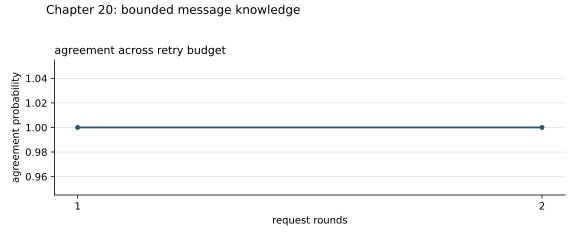

In [4]:
changed_inputs = {'rounds': 2, 'drop_probability': 0}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 20.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

At d=0.5 and R=3, Bob-only commitment is 0.75^3-0.5^3=0.296875. Agreement is 0.703125. Compute that before opening the generated result, then compare it with enumeration.

For a local handoff protocol, map which messages each participant can observe and what decision each view permits. Include dropped replies and partial histories. If a release requires evidence that the other party received an acknowledgement, an unobserved send is insufficient. Export a procedure with receipt requirements and stop conditions rather than calling the protocol successful because some world reaches completion.

In [5]:
transfer_inputs = {'rounds': 3, 'drop_probability': 0.5}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 20: bounded-message-knowledge
What can each party know after a request and an acknowledgement can be dropped?
Evidence: constructed transfer example

Calculated quantities:
{
  "enumerated_worlds": 64,
  "possible_worlds": 64,
  "agreement_probability": 0.703125,
  "alice_knows_delivery_probability": 0.578125,
  "bob_knows_ack_receipt_probability": 0.0,
  "bob_commits_without_alice_probability": 0.296875
}

Interpretation:
Alice commits after an acknowledgement; Bob commits after a request. Local knowledge is checked over indistinguishable positive-probability bounded histories.

Assumptions:
- Independent drops per message opportunity.
- Bob does not observe whether his acknowledgement arrived.
- The model contains a fixed bounded number of rounds.

Limitations:
- Finite agreement probability is not common knowledge or an asynchronous consensus theorem.
- No hidden timeout, failure detector, or extra receipt is assumed.

Execution: completed locally; constructed inputs are not

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **rounds:** Integer request/acknowledgement rounds 1..6; enumeration has 2^(2 rounds) worlds.
- **drop_probability:** Independent per-message drop probability in [0,1].

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch20.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 20: bounded-message-knowledge
What can each party know after a request and an acknowledgement can be dropped?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "enumerated_worlds": 64,
  "possible_worlds": 64,
  "agreement_probability": 0.703125,
  "alice_knows_delivery_probability": 0.578125,
  "bob_knows_ack_receipt_probability": 0.0,
  "bob_commits_without_alice_probability": 0.296875
}

Interpretation:
Alice commits after an acknowledgement; Bob commits after a request. Local knowledge is checked over indistinguishable positive-probability bounded histories.

Assumptions:
- Independent drops per message opportunity.
- Bob does not observe whether his acknowledgement arrived.
- The model contains a fixed bounded number of rounds.

Limitations:
- Finite agreement probability is not common knowledge or an asynchronous consensus theorem.
- No hidden timeout, failure detector, or extra receipt is assumed.

Execution: completed loc

## Questions

1. Compute default disagreement.

2. Why can Bob know acknowledgement receipt at zero drops?

3. Compute transfer agreement.

Answers: [separate solutions](../solutions/ch20.md). Try the calculation before opening them.

## Summary

Messages create different local views. Bounded enumeration checks what follows from those views under a declared drop model and separates agreement from knowledge. The default has a measurable split-decision probability; zero drops remove that split by assumption; the transfer case checks the analytic formula. This is a finite protocol diagnostic, not proof of common knowledge, fault tolerance, or general consensus. Keep receipt requirements and model assumptions explicit.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-20-bounded-message-knowledge`](../skills/maa-20-bounded-message-knowledge/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 20.1

![Equation 20.1](../assets/math/f8ef23bd6086319132c4.svg)

Defines each next mutual-knowledge level by having every party know preceding level.

First level means every party knows F; each later level wraps that group condition once more.

LaTeX source, preserved for inspection:

```latex
\operatorname{MK}_{\mathcal P}^{n+1}(F) = \bigwedge_{i \in \mathcal P} \operatorname{Know}_i\!\left(\operatorname{MK}_{\mathcal P}^{n}(F)\right), \qquad \operatorname{MK}_{\mathcal P}^{1}(F) = \bigwedge_{i \in \mathcal P} \operatorname{Know}_i(F).\tag{20.1}
```

### Equation 20.2

![Equation 20.2](../assets/math/fdc2593e0526f40abc3c.svg)

Defines common knowledge as every finite mutual-knowledge level holding together.

Common knowledge requires no final depth: levels one, two, and every higher finite level hold.

LaTeX source, preserved for inspection:

```latex
\operatorname{CK}_{\mathcal P}(F) \quad\Longleftrightarrow\quad \bigwedge_{n=1}^{\infty} \operatorname{MK}_{\mathcal P}^{n}(F).\tag{20.2}
```